## Задание

Создайте автокодировщик, удаляющий черные квадраты в случайных областях изображений.

Алгоритм действий:
1. Возьмите базу картинок Mnist.
2. На картинках в случайных местах сделайте чёрные квадраты размера 8 на 8.
3. Создайте и обучите автокодировщик восстанавливать оригинальные изображения из "зашумленных" квадратом изображений.
4. Добейтесь MSE < 0.0070 на тестовой выборке

## Импорт библиотек

In [1]:
# Отображение
import matplotlib.pyplot as plt

# Для работы с тензорами
import numpy as np

# Класс создания модели
from tensorflow.keras.models import Model

# Для загрузки данных
from tensorflow.keras.datasets import mnist

# Необходимые слои
from tensorflow.keras.layers import Input, Conv2DTranspose, MaxPooling2D, Conv2D, BatchNormalization

# Оптимизатор
from tensorflow.keras.optimizers import Adam

## Данные

In [2]:
# Загрузка данных
(X_train, y_train), (X_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
# Нормировка данных
X_train = X_train.astype('float32')/255.
X_test = X_test.astype('float32')/255.

In [4]:
# Изменение формы под удобную для Keras
X_train = X_train.reshape((-1, 28, 28, 1))
X_test = X_test.reshape((-1, 28, 28, 1))

In [5]:
# Функция добавления черного квадрата 8x8
# в случайную область изображения
def add_black_square(images, square_size=8):

    # Создаем копию изображений,
    noisy_images = images.copy()

    for img in noisy_images:

        # Случайно выбираем координаты
        # верхнего левого угла квадрата
        x = np.random.randint(0, 28 - square_size)
        y = np.random.randint(0, 28 - square_size)

        # Закрашиваем область размером 8x8 в черный цвет
        # Значение 0 соответствует черному пикселю
        img[
            x:x + square_size,
            y:y + square_size,
            :
        ] = 0

    # Возвращаем зашумленные изображения
    return noisy_images


# Создаем зашумленную обучающую выборку
X_train_noisy = add_black_square(X_train)

# Создаем зашумленную тестовую выборку
X_test_noisy = add_black_square(X_test)

# Проверка размеров массивов
print("X_train_noisy:", X_train_noisy.shape)
print("X_train:", X_train.shape)

print("X_test_noisy:", X_test_noisy.shape)
print("X_test:", X_test.shape)

X_train_noisy: (60000, 28, 28, 1)
X_train: (60000, 28, 28, 1)
X_test_noisy: (10000, 28, 28, 1)
X_test: (10000, 28, 28, 1)


In [6]:
# Входное изображение размером 28x28x1
input_img = Input(shape=(28, 28, 1))

# ENCODER

x = Conv2D(
    32,
    (3, 3),
    activation='relu',
    padding='same'
)(input_img)


x = BatchNormalization()(x)

x = Conv2D(
    32,
    (3, 3),
    activation='relu',
    padding='same'
)(x)

# Уменьшение размера изображения:
# 28x28 -> 14x14
x = MaxPooling2D(
    (2, 2),
    padding='same'
)(x)

x = Conv2D(
    64,
    (3, 3),
    activation='relu',
    padding='same'
)(x)

# Нормализация
x = BatchNormalization()(x)

# Четвертый сверточный слой
x = Conv2D(
    64,
    (3, 3),
    activation='relu',
    padding='same'
)(x)

# Второе уменьшение размера:
# 14x14 -> 7x7
x = MaxPooling2D(
    (2, 2),
    padding='same'
)(x)

# DECODER

# Первый слой восстановления:
# увеличивает размер изображения
# 7x7 -> 14x14
x = Conv2DTranspose(
    64,
    (3, 3),
    strides=2,
    activation='relu',
    padding='same'
)(x)

x = BatchNormalization()(x)

# Второй слой восстановления:
# 14x14 -> 28x28
x = Conv2DTranspose(
    32,
    (3, 3),
    strides=2,
    activation='relu',
    padding='same'
)(x)

x = BatchNormalization()(x)

# формирует итоговое восстановленное изображение
output_img = Conv2D(
    1,
    (3, 3),
    activation='sigmoid',
    padding='same'
)(x)

# вход -> encoder -> decoder -> восстановленное изображение
autoencoder = Model(
    input_img,
    output_img
)

# Компиляция модели
autoencoder.compile(

    optimizer=Adam(learning_rate=0.001),

    loss='mse'
)

# Вывод архитектуры модели
autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 14, 14, 64)     │        36,928 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 28, 28, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,441 (474.38 KB)

 Trainable params: 121,057 (472.88 KB)

 Non-trainable params: 384 (1.50 KB)

In [7]:
history = autoencoder.fit(
    X_train_noisy,
    X_train,
    epochs=20,
    batch_size=128,
    shuffle=True,
    validation_data=(X_test_noisy, X_test)
)

Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 20s 25ms/step - loss: 0.0186 - val_loss: 0.0237
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - loss: 0.0065 - val_loss: 0.0060
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - loss: 0.0056 - val_loss: 0.0055
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - loss: 0.0051 - val_loss: 0.0057
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - loss: 0.0048 - val_loss: 0.0048
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - loss: 0.0046 - val_loss: 0.0055
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - loss: 0.0044 - val_loss: 0.0046
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - loss: 0.0043 - val_loss: 0.0044
Epoch 9/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - loss: 0.0041 - val_loss: 0.0043
Epoch 10/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - loss: 0.0040 - val_loss: 0.0050
Epoch 11/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - loss: 0.0039 - val_loss: 0.0043
Epoch 12/20
469/469 ━━━━━━━━━━━━━━━━━━━

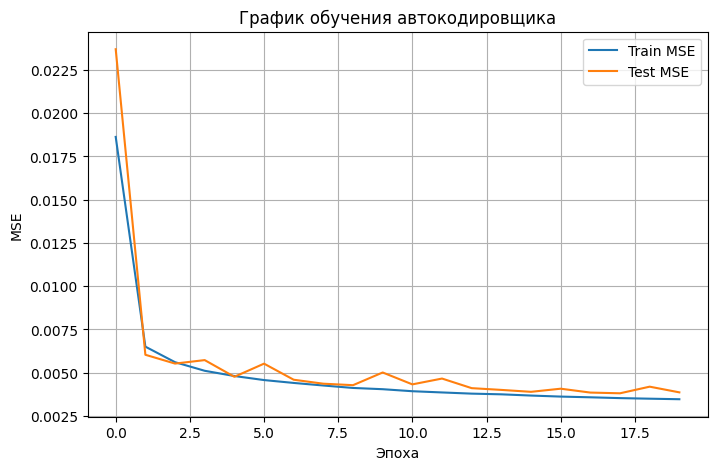

In [8]:
# График обучения
plt.figure(figsize=(8, 5))

plt.plot(history.history['loss'], label='Train MSE')
plt.plot(history.history['val_loss'], label='Test MSE')

plt.title('График обучения автокодировщика')
plt.xlabel('Эпоха')
plt.ylabel('MSE')
plt.legend()
plt.grid(True)

plt.show()

In [9]:
test_mse = autoencoder.evaluate(X_test_noisy, X_test)
print("Test MSE:", test_mse)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0039
Test MSE: 0.003864771220833063


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 632ms/step


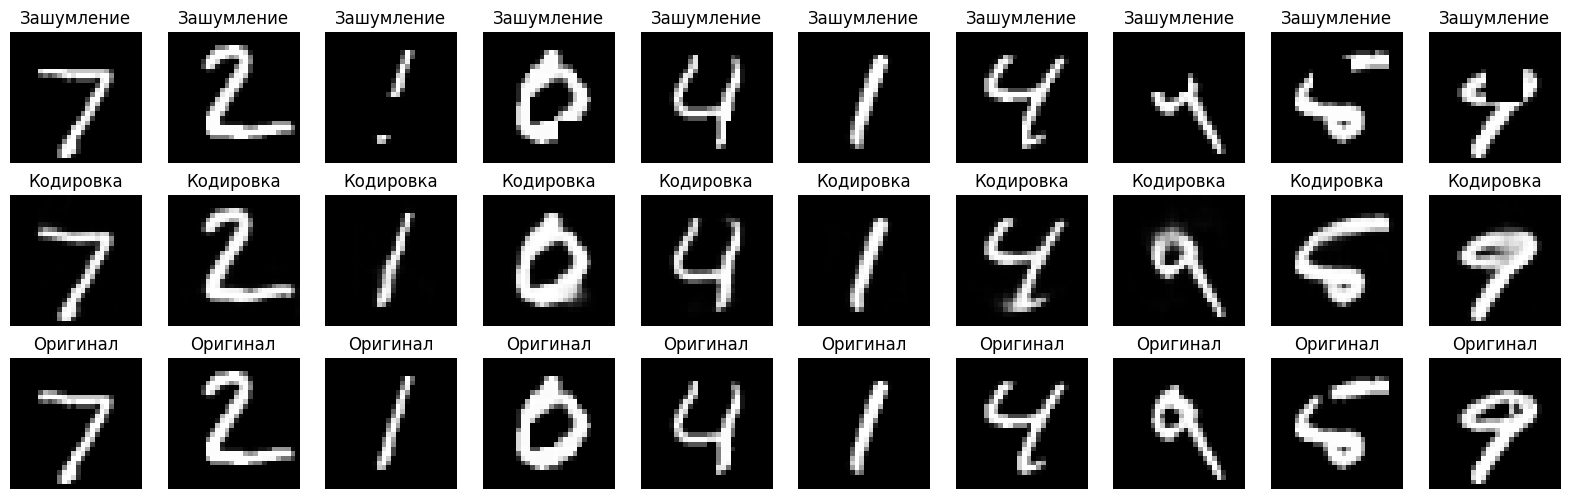

In [10]:
decoded_imgs = autoencoder.predict(X_test_noisy[:10])

plt.figure(figsize=(20, 6))

for i in range(10):
    # Зашумленное изображение
    plt.subplot(3, 10, i + 1)
    plt.imshow(X_test_noisy[i].reshape(28, 28), cmap='gray')
    plt.title("Зашумление")
    plt.axis('off')

    # Восстановленное изображение
    plt.subplot(3, 10, i + 11)
    plt.imshow(decoded_imgs[i].reshape(28, 28), cmap='gray')
    plt.title("Кодировка")
    plt.axis('off')

    # Оригинал
    plt.subplot(3, 10, i + 21)
    plt.imshow(X_test[i].reshape(28, 28), cmap='gray')
    plt.title("Оригинал")
    plt.axis('off')

plt.show()